In [10]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [13]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Розмір навчальної вибірки:", x_train.shape)
print("Розмір тестової вибірки:", x_test.shape)
print("Кількість навчальних міток:", y_train.shape)
print("Кількість тестових міток:", y_test.shape)

Розмір навчальної вибірки: (60000, 28, 28)
Розмір тестової вибірки: (10000, 28, 28)
Кількість навчальних міток: (60000,)
Кількість тестових міток: (10000,)


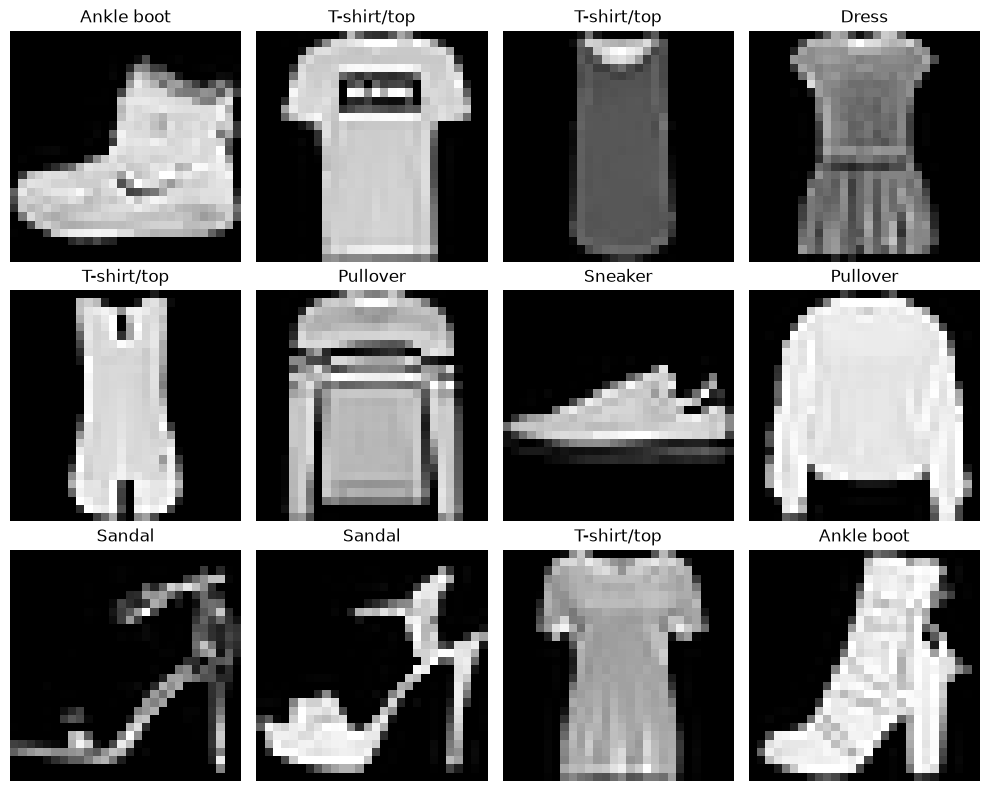

In [14]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(10, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Нова форма x_train:", x_train.shape)
print("Нова форма x_test:", x_test.shape)

Нова форма x_train: (60000, 28, 28, 1)
Нова форма x_test: (10000, 28, 28, 1)


In [16]:
def create_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Dropout(0.25),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),

        layers.Dense(10, activation="softmax")
    ])

    return model


model_example = create_cnn_model()
model_example.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
optimizers = {
    "Adam": Adam(learning_rate=0.001),
    "SGD": SGD(learning_rate=0.01, momentum=0.9),
    "RMSprop": RMSprop(learning_rate=0.001)
}

histories = {}
trained_models = {}
results = []

EPOCHS = 8
BATCH_SIZE = 128

In [18]:
for optimizer_name, optimizer in optimizers.items():
    print("\n" + "=" * 60)
    print("Навчання моделі з оптимізатором:", optimizer_name)
    print("=" * 60)

    model = create_cnn_model()

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.15,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    histories[optimizer_name] = history
    trained_models[optimizer_name] = model

    results.append({
        "Optimizer": optimizer_name,
        "Test loss": test_loss,
        "Test accuracy": test_accuracy
    })

    print(f"Точність на тестових даних: {test_accuracy:.4f}")



Навчання моделі з оптимізатором: Adam
Epoch 1/8
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7971 - loss: 0.5643 - val_accuracy: 0.8709 - val_loss: 0.3705
Epoch 2/8
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8672 - loss: 0.3672 - val_accuracy: 0.8840 - val_loss: 0.3122
Epoch 3/8
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8853 - loss: 0.3181 - val_accuracy: 0.8880 - val_loss: 0.2957
Epoch 4/8
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8958 - loss: 0.2853 - val_accuracy: 0.8997 - val_loss: 0.2707
Epoch 5/8
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9043 - loss: 0.2628 - val_accuracy: 0.9033 - val_loss: 0.2564
Epoch 6/8
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9093 - loss: 0.2472 - val_accuracy: 0.9106 - val_loss: 0.2399
Epoch 7/8
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9130 - loss: 0.2350 - val_accuracy: 0.9159 - val_loss: 0.2370
Epoch 8/8
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy

In [19]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="Test accuracy",
    ascending=False
).reset_index(drop=True)

results_df["Test loss"] = results_df["Test loss"].round(4)
results_df["Test accuracy"] = results_df["Test accuracy"].round(4)

results_df

,Optimizer,Test loss,Test accuracy
0,Adam,0.2427,0.9114
1,RMSprop,0.2522,0.9083
2,SGD,0.3149,0.8813


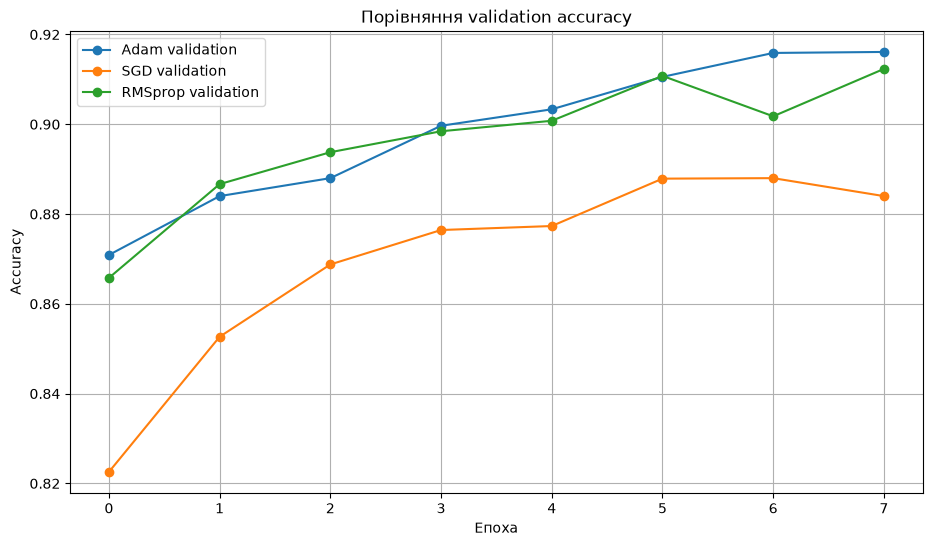

In [20]:
plt.figure(figsize=(11, 6))

for optimizer_name, history in histories.items():
    plt.plot(
        history.history["val_accuracy"],
        marker="o",
        label=f"{optimizer_name} validation"
    )

plt.title("Порівняння validation accuracy")
plt.xlabel("Епоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

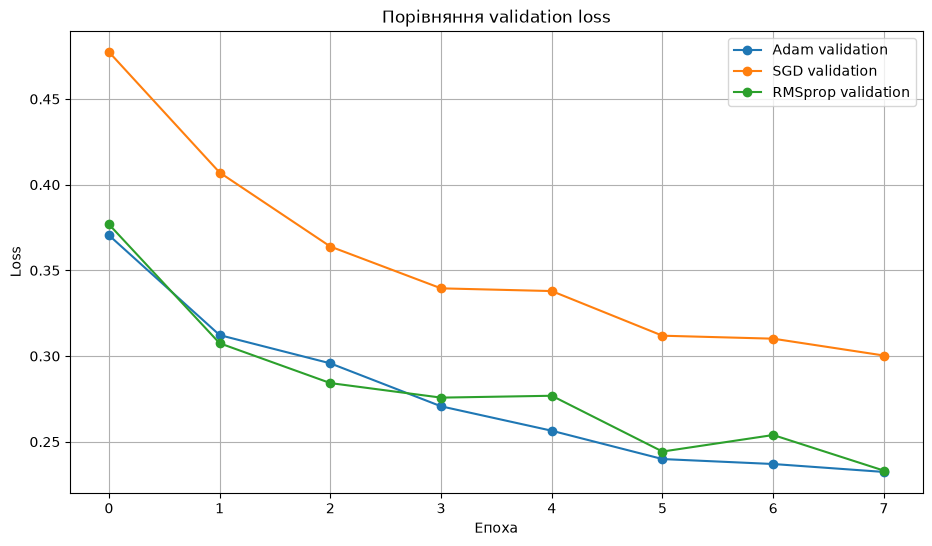

In [21]:
plt.figure(figsize=(11, 6))

for optimizer_name, history in histories.items():
    plt.plot(
        history.history["val_loss"],
        marker="o",
        label=f"{optimizer_name} validation"
    )

plt.title("Порівняння validation loss")
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
best_optimizer_name = results_df.iloc[0]["Optimizer"]
best_model = trained_models[best_optimizer_name]

print("Найкращий оптимізатор:", best_optimizer_name)

predictions = best_model.predict(x_test, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

print("\nClassification report:\n")
print(
    classification_report(
        y_test,
        predicted_classes,
        target_names=class_names
    )
)

Найкращий оптимізатор: Adam

Classification report:

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.89      0.87      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.84      0.89      0.87      1000
       Dress       0.87      0.95      0.91      1000
        Coat       0.87      0.83      0.85      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.80      0.69      0.74      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



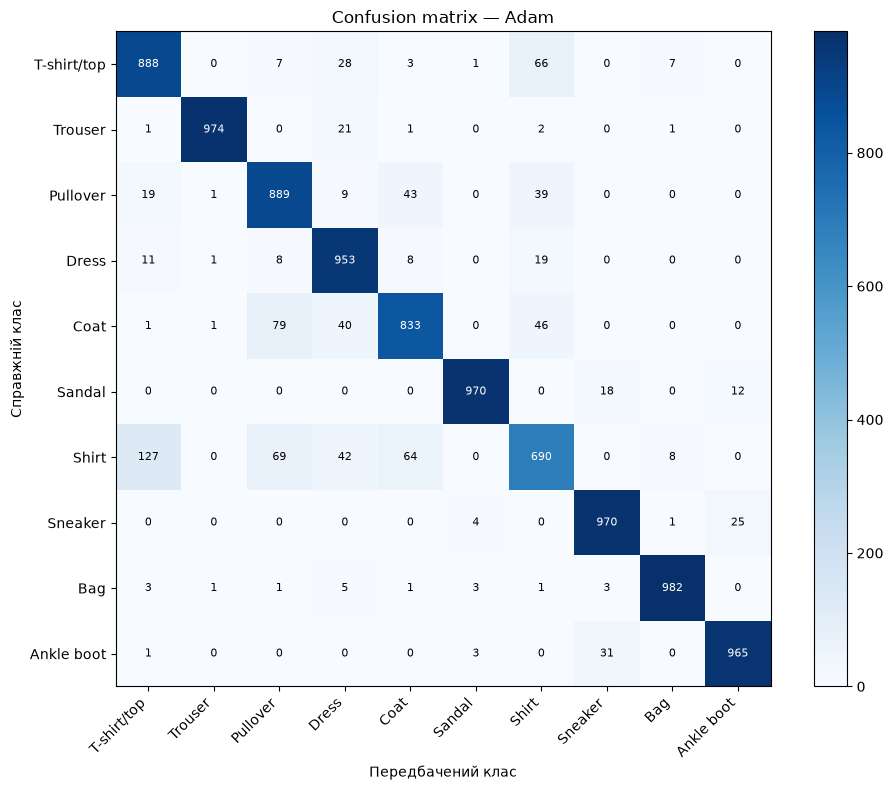

In [23]:
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion matrix — {best_optimizer_name}")
plt.xlabel("Передбачений клас")
plt.ylabel("Справжній клас")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=8
        )

plt.tight_layout()
plt.show()

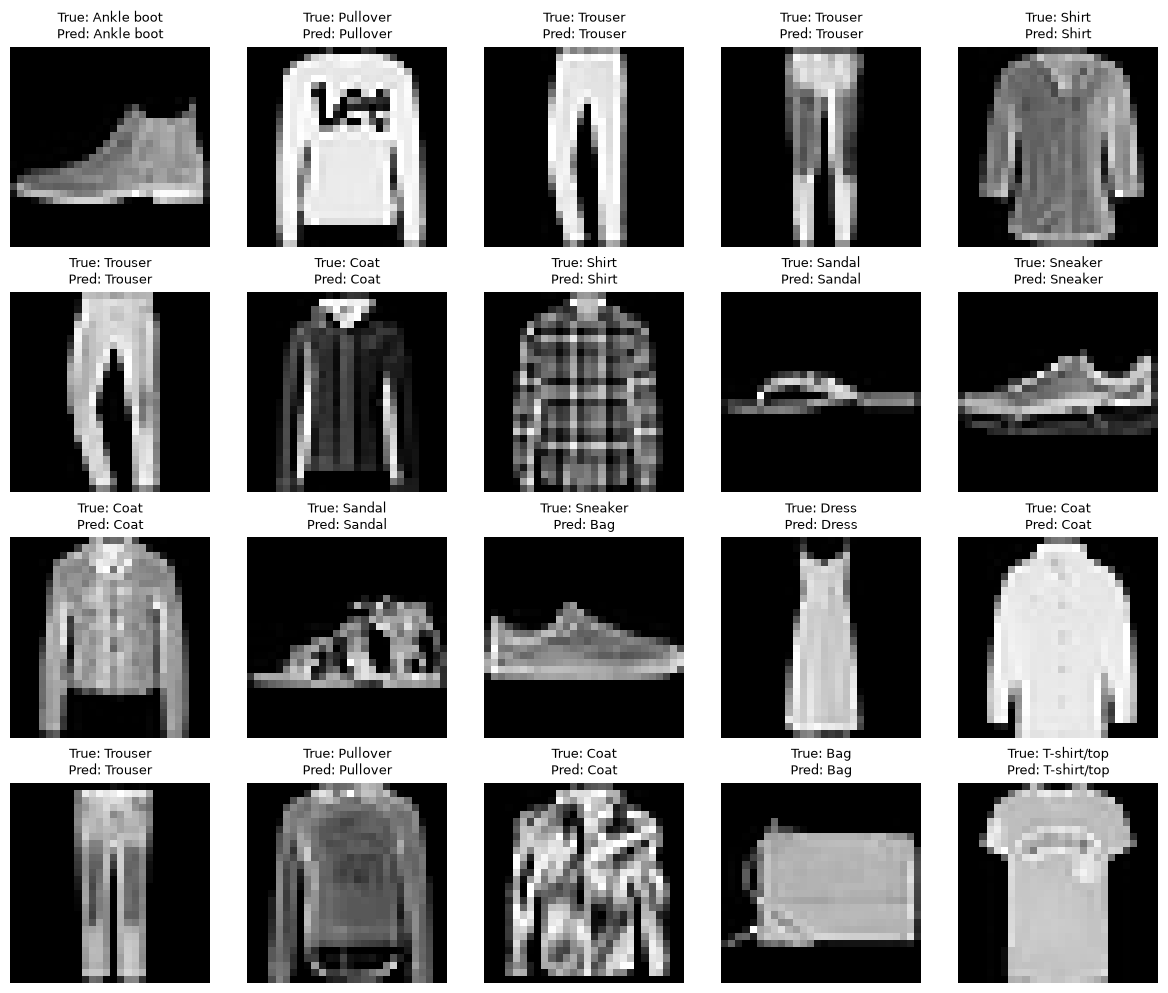

In [24]:
plt.figure(figsize=(12, 10))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")

    true_name = class_names[y_test[i]]
    predicted_name = class_names[predicted_classes[i]]

    plt.title(
        f"True: {true_name}\nPred: {predicted_name}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
learning_rates = [0.0001, 0.001, 0.01]
lr_results = []

for lr in learning_rates:
    print("\nНавчання Adam з learning_rate =", lr)

    model = create_cnn_model()

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=4,
        batch_size=BATCH_SIZE,
        validation_split=0.15,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    lr_results.append({
        "Learning rate": lr,
        "Test loss": round(test_loss, 4),
        "Test accuracy": round(test_accuracy, 4)
    })

pd.DataFrame(lr_results)


Навчання Adam з learning_rate = 0.0001
Epoch 1/4
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6615 - loss: 0.9840 - val_accuracy: 0.7952 - val_loss: 0.5632
Epoch 2/4
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.7901 - loss: 0.5787 - val_accuracy: 0.8257 - val_loss: 0.4752
Epoch 3/4
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8180 - loss: 0.5057 - val_accuracy: 0.8382 - val_loss: 0.4355
Epoch 4/4
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8357 - loss: 0.4629 - val_accuracy: 0.8538 - val_loss: 0.4093

Навчання Adam з learning_rate = 0.001
Epoch 1/4
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.7983 - loss: 0.5590 - val_accuracy: 0.8684 - val_loss: 0.3652
Epoch 2/4
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8700 - loss: 0.3623 - val_accuracy: 0.8786 - val_loss: 0.3312
Epoch 3/4
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8854 - loss: 0.3140 - val_accuracy: 0.8917 - val_loss: 0.2843
Epoch 4/4
399/399 ━━━━

,Learning rate,Test loss,Test accuracy
0,0.0001,0.4187,0.8508
1,0.0010,0.2928,0.8927
2,0.0100,0.2860,0.8965
